In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

df = pd.read_csv(r"C:\Users\김양일\Desktop\Team_Project\data\processed\02_의료기관1_v2.csv")

print(df.head())

    지역  65세이상  고령인구비율  의료기관수  보건지소  보건진료소  고령인구 대비 민간 의료기관 밀도
0   동면   1020   54.72      0     1      1                0.00
1  성남면   1328   48.57      0     1      2                0.00
2  수신면    946   47.73      0     1      1                0.00
3  광덕면   1857   47.01      0     1      2                0.00
4  일봉동   4144   17.11      1     0      0                0.24


In [31]:
df_top10 = df.head(10)
print(df_top10)

     지역  65세이상  고령인구비율  의료기관수  보건지소  보건진료소  고령인구 대비 민간 의료기관 밀도
0    동면   1020   54.72      0     1      1                0.00
1   성남면   1328   48.57      0     1      2                0.00
2   수신면    946   47.73      0     1      1                0.00
3   광덕면   1857   47.01      0     1      2                0.00
4   일봉동   4144   17.11      1     0      0                0.24
5    북면   1726   43.41      2     1      1                1.16
6   성거읍   4218   19.83      6     1      0                1.42
7   봉명동   3498   20.52      6     0      0                1.72
8   풍세면   2216   20.99      5     1      2                2.26
9  원성2동   2856   33.63      7     0      0                2.45


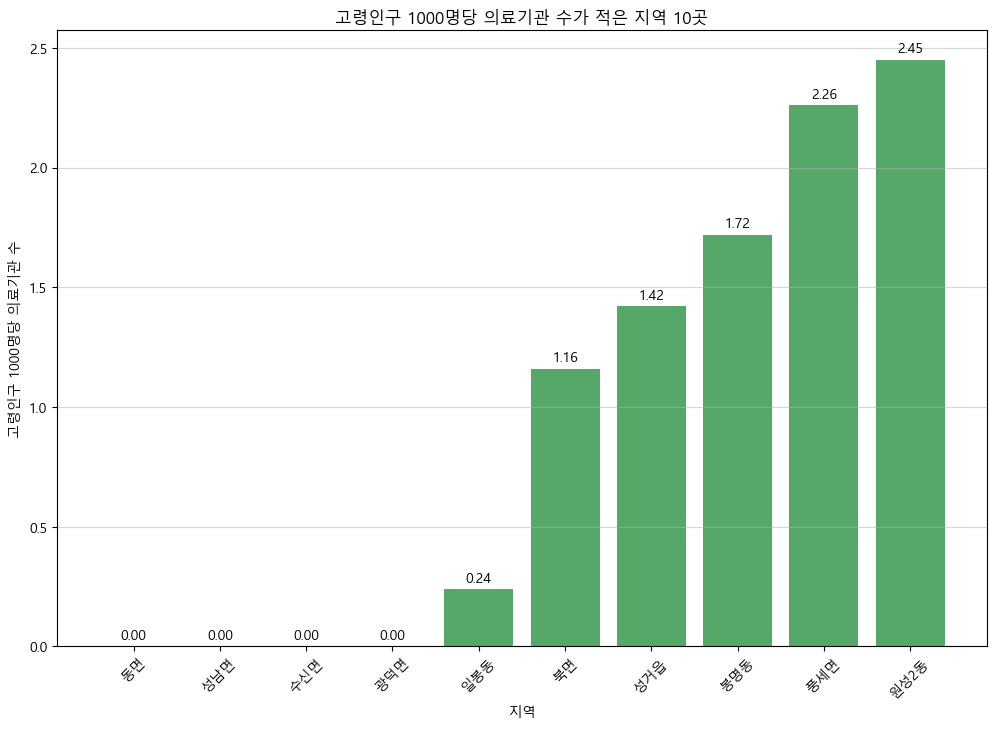

In [32]:
matplotlib.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 8))
bars = plt.bar(
    df_top10["지역"],
    df_top10["고령인구 대비 민간 의료기관 밀도"],
    color = "#55A868"
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.2f}",
        ha="center"
    )

plt.title("고령인구 1000명당 의료기관 수가 적은 지역 10곳")
plt.xlabel("지역")
plt.ylabel("고령인구 1000명당 의료기관 수")
plt.grid(axis="y", alpha=0.5)
plt.xticks(rotation=45)

plt.show()

In [55]:
df2 = df.sort_values(["의료기관수","보건지소","보건진료소"])
df2 = df2[["지역","65세이상", "고령인구비율", "의료기관수","보건지소","보건진료소"]]

print(df2.head(10))

     지역  65세이상  고령인구비율  의료기관수  보건지소  보건진료소
0    동면   1020   54.72      0     1      1
2   수신면    946   47.73      0     1      1
1   성남면   1328   48.57      0     1      2
3   광덕면   1857   47.01      0     1      2
4   일봉동   4144   17.11      1     0      0
5    북면   1726   43.41      2     1      1
8   풍세면   2216   20.99      5     1      2
7   봉명동   3498   20.52      6     0      0
6   성거읍   4218   19.83      6     1      0
9  원성2동   2856   33.63      7     0      0


In [59]:
df2["공공 기관 수"] = df["보건지소"] + df["보건진료소"]
df3 = df2[["지역", "65세이상", "고령인구비율", "의료기관수", "공공 기관 수"]]

df3.to_csv(r"C:\Users\김양일\Desktop\Team_Project\data\processed\02_의료기관1_v3.csv",
           index=False,
           encoding="utf-8-sig")

print(df3.head(10))


     지역  65세이상  고령인구비율  의료기관수  공공 기관 수
0    동면   1020   54.72      0        2
2   수신면    946   47.73      0        2
1   성남면   1328   48.57      0        3
3   광덕면   1857   47.01      0        3
4   일봉동   4144   17.11      1        0
5    북면   1726   43.41      2        2
8   풍세면   2216   20.99      5        3
7   봉명동   3498   20.52      6        0
6   성거읍   4218   19.83      6        1
9  원성2동   2856   33.63      7        0


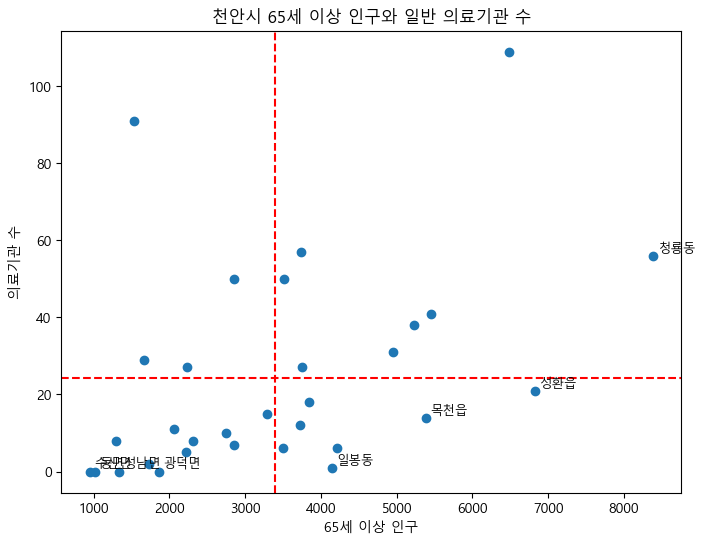

In [47]:
avg_old = df3["65세이상"].mean()
avg_med = df3["의료기관수"].mean()

plt.figure(figsize=(8,6))

plt.scatter(
    df3["65세이상"],
    df3["의료기관수"]
)

highlight = ["성환읍", "목천읍", "일봉동", "청룡동", "동면", "성남면", "수신면", "광덕면"]

for i in range(len(df3)):

    if df3["지역"].iloc[i] in highlight:

        plt.text(
            df3["65세이상"].iloc[i] + 60,
            df3["의료기관수"].iloc[i] + 1,
            df3["지역"].iloc[i],
            fontsize=9
        )

plt.xlabel("65세 이상 인구")
plt.ylabel("의료기관 수")
plt.title("천안시 65세 이상 인구와 일반 의료기관 수")
plt.axvline(
    avg_old,
    color="red",
    linestyle="--"
)

plt.axhline(
    avg_med,
    color="red",
    linestyle="--"
)

plt.show()

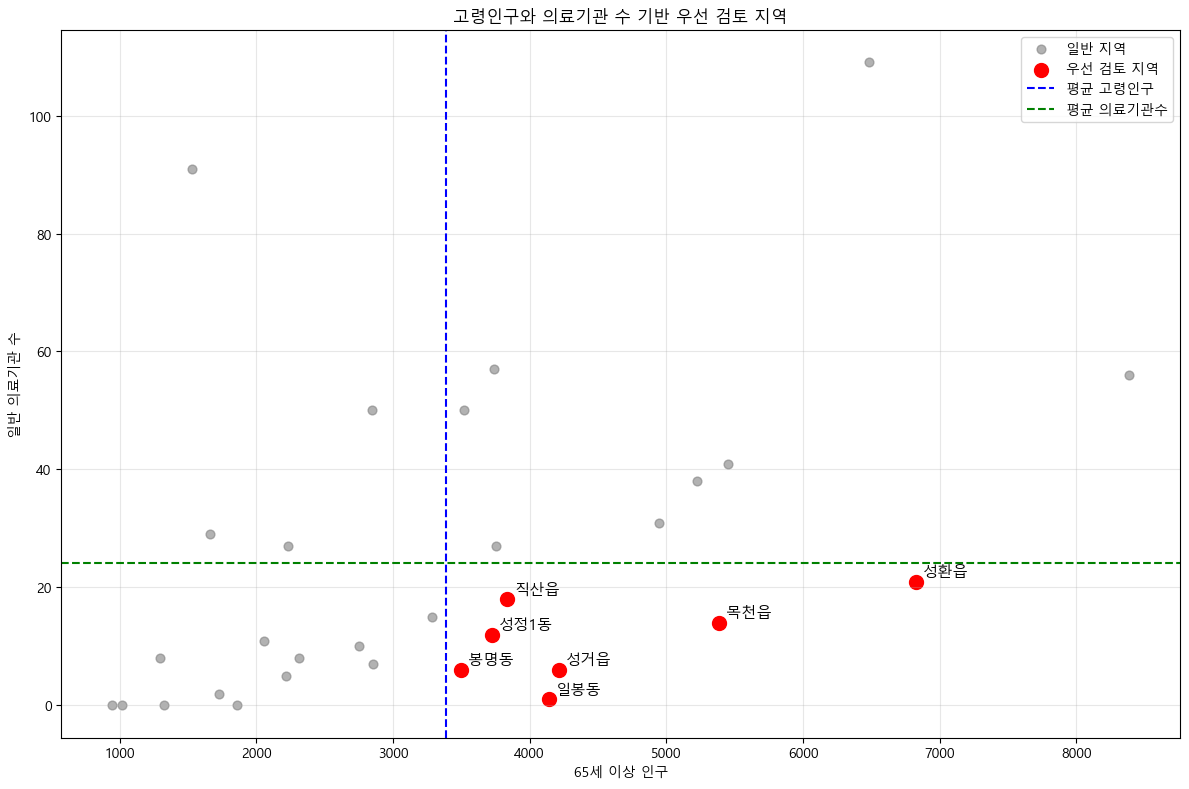

In [ ]:
avg_old = df3["65세이상"].mean()
avg_med = df3["의료기관수"].mean()

priority_mask = (
    (df3["65세이상"] >= avg_old) &
    (df3["의료기관수"] < avg_med)
)

normal_df = df3[~priority_mask]
priority_df = df3[priority_mask]

plt.figure(figsize=(12, 8))

plt.scatter(
    normal_df["65세이상"],
    normal_df["의료기관수"],
    color="gray",
    alpha=0.6,
    label="일반 지역"
)

plt.scatter(
    priority_df["65세이상"],
    priority_df["의료기관수"],
    color="red",
    s=100,
    label="우선 검토 지역"
)

plt.axvline(
    avg_old,
    color="blue",
    linestyle="--",
    label="평균 고령인구"
)

plt.axhline(
    avg_med,
    color="green",
    linestyle="--",
    label="평균 의료기관수"
)

for _, row in priority_df.iterrows():
    plt.text(
        row["65세이상"] + 50,
        row["의료기관수"] + 1,
        row["지역"],
        fontsize=11
    )


plt.title("고령인구와 의료기관 수 기반 우선 검토 지역")
plt.xlabel("65세 이상 인구")
plt.ylabel("일반 의료기관 수")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()


plt.savefig(
    "고령인구와 의료기관 수 기반 우선 검토 지역.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()